# 02 — Profitability by Region
Total sales, profit, and margin compared across geographic regions.


In [1]:
from pyhive import hive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("muted")

def get_conn():
    return hive.connect(host="hive-server2", port=10000,
                        database="default", auth="NONE")

def fetch_df(cur, sql):
    cur.execute(sql)
    cols = [d[0].split(".")[-1] for d in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def fmt_usd(v):
    if abs(v) >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if abs(v) >= 1_000:
        return f"${v/1_000:.1f}K"
    return f"${v:.0f}"

conn = get_conn()
cur  = conn.cursor()
print("Connected.")


Connected.


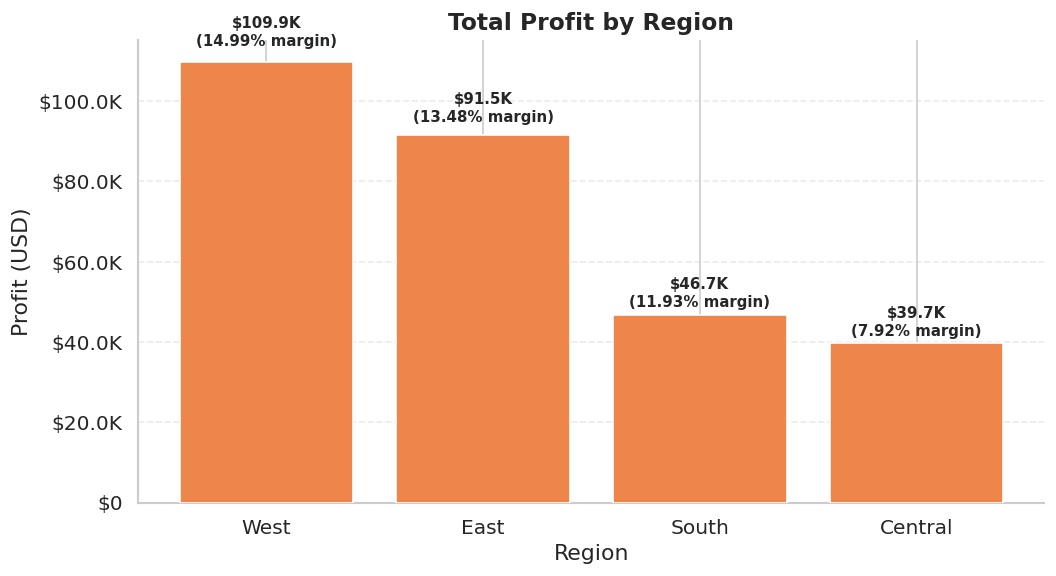

In [2]:
# ── Profitability by Region ───────────────────────────────────────────────────
region = fetch_df(cur, """
    SELECT l.region,
           ROUND(SUM(oi.sales),  2)                      AS sales,
           ROUND(SUM(oi.profit), 2)                      AS profit,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100, 2)   AS margin_pct
    FROM orders o
    JOIN order_items oi ON o.order_id  = oi.order_id
    JOIN locations   l  ON o.postal_code = l.postal_code
    GROUP BY l.region
    ORDER BY profit DESC
""")

colors = [PALETTE[1] if v >= 0 else PALETTE[3] for v in region["profit"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(region["region"], region["profit"],
              color=colors, edgecolor="white", zorder=3)

for bar, mg in zip(bars, region["margin_pct"]):
    h      = bar.get_height()
    offset = max(abs(h) * 0.03, 500)
    sign   = 1 if h >= 0 else -1
    ax.text(bar.get_x() + bar.get_width()/2,
            h + sign * offset,
            f"{fmt_usd(h)}\n({mg}% margin)",
            ha="center", va="bottom" if h >= 0 else "top",
            fontsize=9, fontweight="bold")

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
ax.set_title("Total Profit by Region")
ax.set_ylabel("Profit (USD)")
ax.set_xlabel("Region")
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()


In [3]:
cur.close()
conn.close()
print("Done.")


Done.
